# Weight Estimation - ResNet50

**Author:** Xián Novoa Gutiérrez  
**Project:** Poultry Vision Monitoring  
**Repository:** https://github.com/xiannovoa/poultry-vision-monitoring

## Introduction

In this notebook, we explore the impact of increasing model capacity by replacing ResNet18 with a deeper pretrained architecture, ResNet50. The goal is to evaluate whether a more expressive model can better capture the visual patterns required for accurate chicken weight estimation.

To ensure a fair comparison, we keep the entire training pipeline identical to *Notebook 03*, including data preprocessing, augmentation, and fine-tuning strategy. Only the backbone architecture is modified. Specifically, we fine-tune the last block of the network while keeping earlier layers frozen, allowing the model to adapt high-level features to the poultry domain while preserving general visual representations.

This experiment aims to determine whether increasing model complexity leads to improved performance, particularly in challenging cases such as larger chickens, where previous models showed higher errors.

**IMPORTANT:** The dataset loading, data augmentation, data preparation, and train/validation split follow exactly the same procedure as in Notebook 03. These steps are not described in detail here in order to avoid redundancy. For a complete explanation of the data pipeline, the reader is referred to *03_weight_estimation_transfer_learning*.

## 1. Dataset

https://huggingface.co/datasets/xiannovoa/poultry-weight-dataset

In [1]:
from datasets import load_dataset, Image
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().resolve()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATASET_PATH = ROOT / "data/03_final/broiler_weight_dataset"

assert DATASET_PATH.exists(), f"Dataset no encontrado en {DATASET_PATH}"

In [2]:
dataset = load_dataset(
    "csv",
    data_files={"train": str(DATASET_PATH / "labels.csv")}
)

In [3]:
def add_full_path(example):
    example["image"] = str(DATASET_PATH / example["image"])
    return example

dataset = dataset.map(add_full_path)

In [4]:
dataset = dataset.cast_column("image", Image())

In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'weight'],
        num_rows: 4761
    })
})


## 2. Data Augmentation

In [6]:
import torchvision.transforms as transforms

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## 3. Data Preparation for Training (PyTorch)

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

In [9]:
class NormalizedPoultryDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, mean=0.0, std=1.0):
        self.dataset = hf_dataset
        self.transform = transform
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = sample["image"]
        weight = sample["weight"]

        if weight is None:
            raise ValueError(f"Missing weight at index {idx}")

        if self.transform:
            image = self.transform(image)

        weight = (float(weight) - self.mean) / self.std
        weight = torch.tensor(weight, dtype=torch.float32)

        return image, weight

## 4. Train / Validation Split

In [10]:
from torch.utils.data import random_split
import numpy as np

In [11]:
from torch.utils.data import random_split

full_dataset = dataset["train"]

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Fix seed for reproducibility
train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train size: {len(train_subset)}")
print(f"Validation size: {len(val_subset)}")

Train size: 3808
Validation size: 953


In [12]:
train_weights = [sample["weight"] for sample in train_subset]

mean_weight = np.mean(train_weights)
std_weight = np.std(train_weights)

print(f"Mean weight: {mean_weight:.2f}")
print(f"Std weight: {std_weight:.2f}")

Mean weight: 470.08
Std weight: 391.41


In [13]:
train_dataset = NormalizedPoultryDataset(
    train_subset,
    transform=train_transform, # With data augmentation
    mean=mean_weight,
    std=std_weight
)

val_dataset = NormalizedPoultryDataset(
    val_subset,
    transform=val_transform, # Without data augmentation
    mean=mean_weight,
    std=std_weight
)

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

## 5. Model

In this stage, we replace the ResNet18 backbone with a deeper pretrained architecture, **ResNet50**, to evaluate the impact of increased model capacity. The rest of the training strategy remains identical to *Notebook 03*, ensuring a fair comparison between architectures.

As in previous experiments, we freeze most of the network and only fine-tune the last block (layer4), allowing the model to adapt high-level features to the poultry domain while preserving general visual representations learned from ImageNet.

This setup allows us to assess whether a more expressive model can better capture complex visual patterns, particularly in challenging cases such as larger chickens, where previous models showed higher errors.

In [15]:
from torchvision import models
from torchvision.models import ResNet50_Weights
import torch.nn as nn

In [16]:
# Load pretrained ResNet50
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block (layer4)
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

# Replace final layer for regression
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

# Move to device
device = torch.device("cpu")
model = model.to(device)

## 6. Training with Validation

The training procedure is kept identical to previous experiments to ensure a fair comparison, allowing us to isolate the effect of increasing model capacity

In [17]:
import torch.optim as optim

# Loss
criterion = nn.MSELoss()

# ONLY the trainable parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

num_epochs = 30

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    train_loss = 0.0

    for images, weights in train_loader:
        images = images.to(device)
        weights = weights.to(device)

        optimizer.zero_grad()

        outputs = model(images).squeeze()
        loss = criterion(outputs, weights)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, weights in val_loader:
            images = images.to(device)
            weights = weights.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, weights)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Epoch [1/30] - Train Loss: 0.3020 - Val Loss: 0.1133
Epoch [2/30] - Train Loss: 0.1148 - Val Loss: 0.0738
Epoch [3/30] - Train Loss: 0.0792 - Val Loss: 0.0694
Epoch [4/30] - Train Loss: 0.0623 - Val Loss: 0.0578
Epoch [5/30] - Train Loss: 0.0489 - Val Loss: 0.0571
Epoch [6/30] - Train Loss: 0.0462 - Val Loss: 0.0482
Epoch [7/30] - Train Loss: 0.0426 - Val Loss: 0.0425
Epoch [8/30] - Train Loss: 0.0327 - Val Loss: 0.0427
Epoch [9/30] - Train Loss: 0.0296 - Val Loss: 0.0371
Epoch [10/30] - Train Loss: 0.0281 - Val Loss: 0.0438
Epoch [11/30] - Train Loss: 0.0244 - Val Loss: 0.0330
Epoch [12/30] - Train Loss: 0.0255 - Val Loss: 0.0346
Epoch [13/30] - Train Loss: 0.0225 - Val Loss: 0.0293
Epoch [14/30] - Train Loss: 0.0198 - Val Loss: 0.0377
Epoch [15/30] - Train Loss: 0.0185 - Val Loss: 0.0278
Epoch [16/30] - Train Loss: 0.0169 - Val Loss: 0.0285
Epoch [17/30] - Train Loss: 0.0172 - Val Loss: 0.0266
Epoch [18/30] - Train Loss: 0.0161 - Val Loss: 0.0268
Epoch [19/30] - Train Loss: 0.0146 - 

### Evaluation (MAE + Relative Error)

We evaluate the model using Mean Absolute Error (MAE) in grams, as well as a **relative error metric to better reflect performance across different weight ranges**.

The relative error is computed as the absolute error divided by the true weight, providing a percentage-based interpretation of the model’s accuracy.

In [18]:
model.eval()

mae = 0.0
relative_error = 0.0

with torch.no_grad():
    for images, weights in val_loader:
        images = images.to(device)
        weights = weights.to(device)

        outputs = model(images).squeeze()

        # Denormalize
        preds = outputs * std_weight + mean_weight
        targets = weights * std_weight + mean_weight

        # MAE
        mae += torch.abs(preds - targets).sum().item()

        # Relative error
        relative_error += (torch.abs(preds - targets) / targets).sum().item()

mae /= len(val_dataset)
relative_error /= len(val_dataset)

print(f"Validation MAE: {mae:.2f} grams")
print(f"Mean Relative Error: {relative_error:.4f} ({relative_error*100:.2f}%)")

Validation MAE: 38.79 grams
Mean Relative Error: 0.1012 (10.12%)


**The results obtained with ResNet50 show a clear improvement over all previous configurations**. Both MAE and relative error are significantly reduced compared to the baseline model in *Notebook 03*, indicating that increasing model capacity has a strong positive impact on performance.

This suggests that the deeper architecture is able to better capture complex visual patterns and scale-related features, which are essential for accurate weight estimation. The improvement is consistent across the dataset, highlighting the importance of model expressiveness over more aggressive preprocessing strategies explored in previous experiments.

### Example Prediction

We visualize a prediction and compare it to the real weight.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

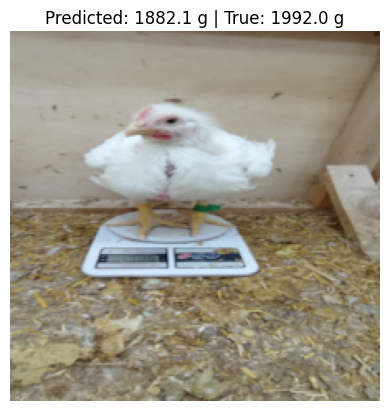

In [19]:
sample = val_dataset[0]

image, weight_norm = sample

model.eval()
with torch.no_grad():
    pred_norm = model(image.unsqueeze(0).to(device)).squeeze().cpu()

pred_weight = pred_norm.item() * std_weight + mean_weight
true_weight = weight_norm.item() * std_weight + mean_weight

img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Predicted: {pred_weight:.1f} g | True: {true_weight:.1f} g")
plt.axis("off")

## 7. Error Analysis by Weight Range (Histogram)

To better understand the model's behavior, we analyze how prediction errors vary across different weight ranges.

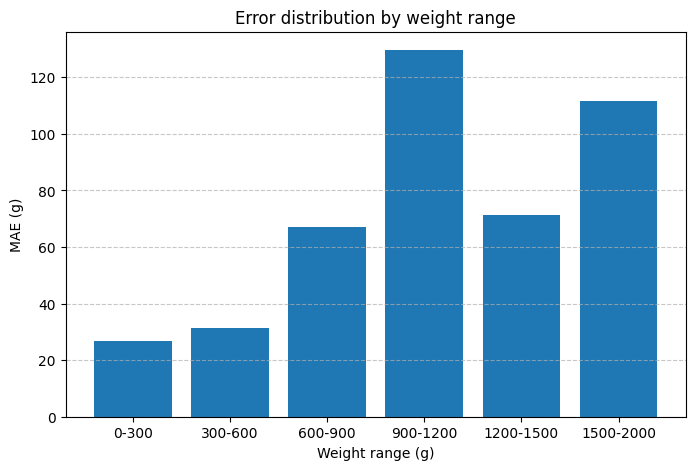

In [20]:
import numpy as np

model.eval()

all_targets = []
all_preds = []

with torch.no_grad():
    for images, weights in val_loader:
        images = images.to(device)
        weights = weights.to(device)

        outputs = model(images).squeeze()

        # Denormalize
        preds = outputs * std_weight + mean_weight
        targets = weights * std_weight + mean_weight

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

errors = np.abs(all_preds - all_targets)

# Define bins
bins = [0, 300, 600, 900, 1200, 1500, 2000]
bin_labels = []
mae_per_bin = []

for i in range(len(bins) - 1):
    mask = (all_targets >= bins[i]) & (all_targets < bins[i+1])
    
    if np.sum(mask) > 0:
        mae = np.mean(errors[mask])
        mae_per_bin.append(mae)
        bin_labels.append(f"{bins[i]}-{bins[i+1]}")

# Plot
plt.figure(figsize=(8,5))
plt.bar(bin_labels, mae_per_bin)

plt.xlabel("Weight range (g)")
plt.ylabel("MAE (g)")
plt.title("Error distribution by weight range")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The error increases with weight, but remains lower and more stable than in previous models. ResNet50 improves performance across all ranges, especially for heavier chickens.

## 8. Model Saving

We save the trained model to reuse it later without retraining.

In [21]:
torch.save(model.state_dict(), "resnet50_weight_estimation_06.pth")

np.save("val_predictions.npy", all_preds)
np.save("val_targets.npy", all_targets)